<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 6: Random Forest and AdaBoost Classification



### Lab Objectives

- Prepare a real-world cloud infrastructure failure dataset for multi-class classification.
- Implement Random Forest and AdaBoost ensemble learning algorithms.
- Compare the predictive performance of both ensemble classifiers.
- Analyze feature importance and classification performance.
- Interpret the effectiveness of ensemble learning for cloud failure prediction.

## Importing Required Libraries

The following libraries are required for data preprocessing, ensemble learning, visualization, and performance evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


## Uploading Dataset B

The OpenStack cloud infrastructure failure dataset is uploaded and extracted. The deployment module is selected because it contains engineered cloud monitoring features together with their corresponding failure labels.

In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall()

print("Dataset extracted successfully.")

Dataset extracted successfully.


## Loading the Selected Dataset

The deployment (DEPL) module is selected from Dataset B. The feature dataset and corresponding failure labels are loaded and merged to create the final machine learning dataset.

In [ ]:
DATASET_B_PATH = "Failure-Dataset-OpenStack-main"

feature_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "LCS_with_VMM.tsv"
)

label_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "Failure_Labels.txt"
)

X_df = pd.read_csv(feature_file, sep="\t")

labels = pd.read_csv(
    label_file,
    header=None,
    names=["Label"]
)

model_df = X_df.copy()

model_df["Label"] = labels["Label"]

print("Dataset loaded successfully.")

display(model_df.head())

Dataset loaded successfully.


,cinderclient_DELETE_202,cinderclient_DELETE_400,cinderclient_DELETE_500,cinderclient_GET_200,cinderclient_GET_400,cinderclient_GET_404,cinderclient_GET_500,cinderclient_POST_200,cinderclient_POST_202,cinderclient_POST_400,...,q-plugin_release_dhcp_port.1,q-plugin_update_device_list.1,q-plugin_update_device_list_ERROR.1,scheduler_delete_instance_info.1,scheduler_delete_instance_info_ERROR.1,scheduler_select_destinations.1,scheduler_select_destinations_ERROR.1,scheduler_update_instance_info.1,scheduler_update_instance_info_ERROR.1,Label
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6


## Dataset Overview

The selected dataset contains engineered cloud infrastructure monitoring features extracted from OpenStack deployment logs. Each observation is associated with one of six failure classes, making it suitable for multi-class classification.

In [ ]:
summary = pd.DataFrame({
    "Property":[
        "Number of Records",
        "Number of Features",
        "Number of Classes"
    ],
    "Value":[
        model_df.shape[0],
        model_df.shape[1]-1,
        model_df["Label"].nunique()
    ]
})

display(summary)

,Property,Value
0,Number of Records,1076
1,Number of Features,208
2,Number of Classes,6


In [ ]:
print("Failure Class Distribution")

display(
    model_df["Label"]
    .value_counts()
    .sort_index()
)

Failure Class Distribution


,count
Label,
1,224
2,151
3,41
4,69
5,52
6,539


## Preparing the Training and Testing Dataset

The dataset is divided into predictor variables and target labels before being split into training and testing subsets for model development and evaluation.

In [ ]:
X = model_df.drop(columns=["Label"])

y = model_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    "Dataset":[
        "Training Samples",
        "Testing Samples",
        "Training Labels",
        "Testing Labels"
    ],
    "Shape":[
        X_train.shape,
        X_test.shape,
        y_train.shape,
        y_test.shape
    ]
})

display(split_summary)

,Dataset,Shape
0,Training Samples,"(860, 208)"
1,Testing Samples,"(216, 208)"
2,Training Labels,"(860,)"
3,Testing Labels,"(216,)"


## Introduction to Ensemble Learning

Ensemble learning combines the predictions of multiple machine learning models to improve classification performance. Random Forest builds multiple decision trees and combines their predictions, whereas AdaBoost sequentially trains weak learners by emphasizing previously misclassified samples.

## Random Forest Classification

Random Forest constructs an ensemble of decision trees using bootstrap sampling and random feature selection. The final prediction is determined through majority voting among the individual trees.

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(X_test)

print("Random Forest trained successfully.")

print(f"\nOut-of-Bag Score : {random_forest.oob_score_:.4f}")

Random Forest trained successfully.

Out-of-Bag Score : 0.9535


## AdaBoost Classification

AdaBoost builds an ensemble of weak learners by iteratively focusing on previously misclassified observations. The final prediction combines the weighted contribution of all learners.

In [ ]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost.fit(
    X_train,
    y_train
)

ada_predictions = adaboost.predict(X_test)

print("AdaBoost trained successfully.")

AdaBoost trained successfully.


## Model Evaluation

The Random Forest and AdaBoost ensemble classifiers are evaluated using weighted classification metrics suitable for multi-class prediction. These metrics provide a comprehensive comparison of the predictive capability of both ensemble learning algorithms.

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

ada_accuracy = accuracy_score(y_test, ada_predictions)
ada_precision = precision_score(
    y_test,
    ada_predictions,
    average="weighted",
    zero_division=0
)
ada_recall = recall_score(
    y_test,
    ada_predictions,
    average="weighted",
    zero_division=0
)
ada_f1 = f1_score(
    y_test,
    ada_predictions,
    average="weighted",
    zero_division=0
)

evaluation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Random Forest":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    "AdaBoost":[
        ada_accuracy,
        ada_precision,
        ada_recall,
        ada_f1
    ]
})

evaluation.iloc[:,1:] = evaluation.iloc[:,1:].round(4)

display(evaluation)

,Metric,Random Forest,AdaBoost
0,Accuracy,0.9676,0.9352
1,Precision,0.9696,0.9378
2,Recall,0.9676,0.9352
3,F1 Score,0.9661,0.9346


## Distribution of Failure Classes

Understanding the class distribution is important before interpreting the model performance. This visualization illustrates the number of observations available for each cloud infrastructure failure class.

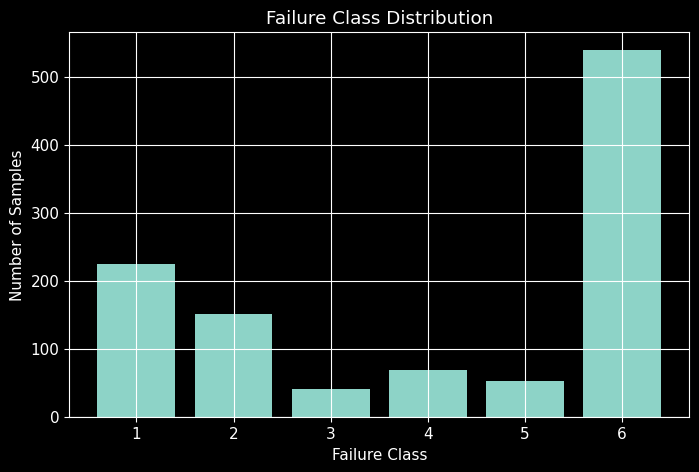

In [ ]:
class_distribution = (
    model_df["Label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    class_distribution.index.astype(str),
    class_distribution.values
)

plt.title("Failure Class Distribution")

plt.xlabel("Failure Class")

plt.ylabel("Number of Samples")

plt.show()

## Confusion Matrix - Random Forest

The confusion matrix illustrates how effectively the Random Forest classifier distinguishes among the six cloud failure classes.

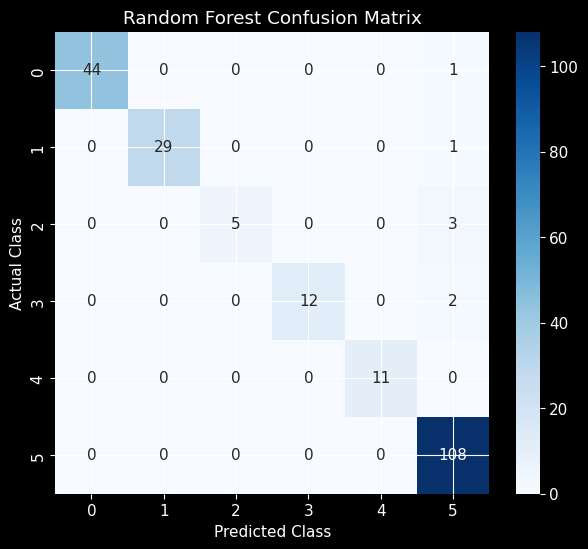

In [ ]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

## Confusion Matrix - AdaBoost

The confusion matrix summarizes the multi-class prediction performance of the AdaBoost classifier by comparing the predicted and actual failure classes.

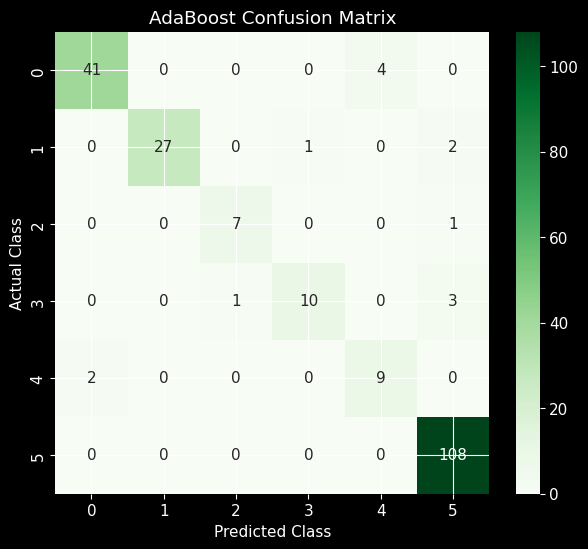

In [ ]:
ada_cm = confusion_matrix(
    y_test,
    ada_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    ada_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("AdaBoost Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

## Top 15 Most Important Features

Ensemble learning algorithms estimate the relative importance of input features during model training. The following comparison highlights the fifteen most influential cloud monitoring features identified by Random Forest and AdaBoost.

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest": random_forest.feature_importances_,
    "AdaBoost": adaboost.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Random Forest",
    ascending=False
).head(15)

display(rf_importance)

,Feature,Random Forest,AdaBoost
118,cinder-volume.localhost.localdomain@lvm_attach...,0.081940,0.066124
124,cinder-volume.localhost.localdomain@lvm_detach...,0.053084,0.000000
107,cinderclient_GET_200.1,0.051486,0.025020
112,cinderclient_POST_202.1,0.050208,0.000000
198,q-plugin_get_ports.1,0.045466,0.023290
126,cinder-volume.localhost.localdomain@lvm_initia...,0.042394,0.000000
169,novaclient_POST_200.1,0.036433,0.010743
151,l3_agent_routers_updated.1,0.036348,0.000000
185,q-firewall-plugin_get_firewalls_for_tenant.1,0.036215,0.000000
111,cinderclient_POST_200.1,0.033862,0.000000


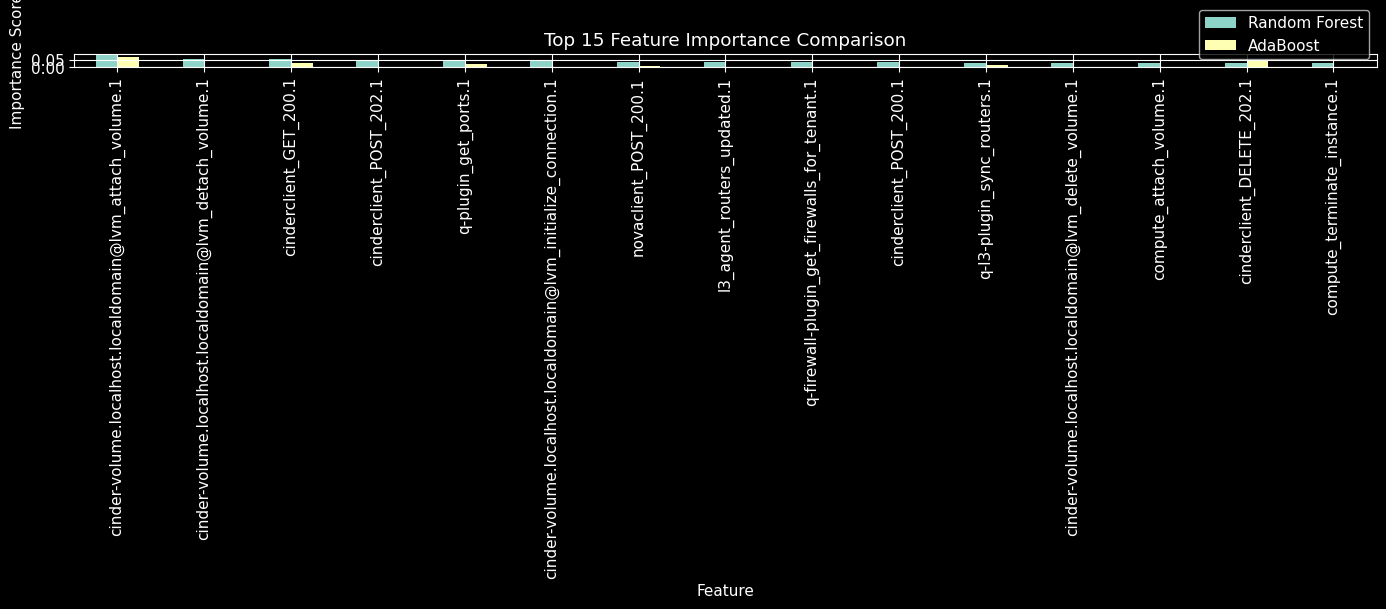

In [ ]:
plot_df = rf_importance.set_index("Feature")

plot_df.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Top 15 Feature Importance Comparison")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()

## Performance Comparison

The following chart compares the overall predictive performance of Random Forest and AdaBoost using the selected weighted evaluation metrics.

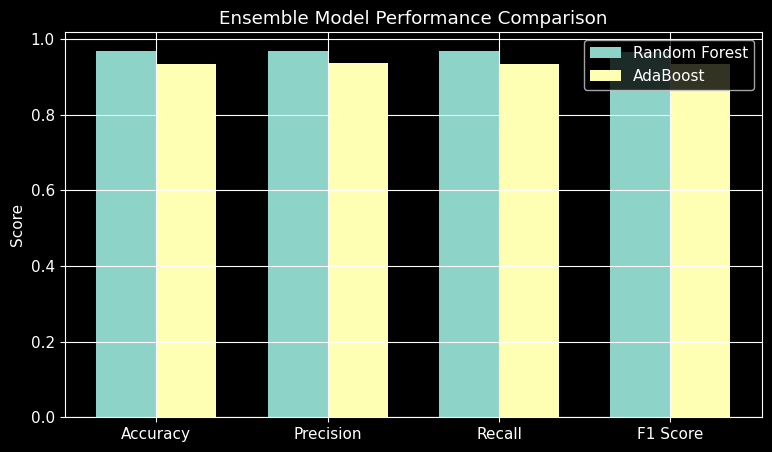

In [ ]:
metrics = evaluation["Metric"]

x = np.arange(len(metrics))

width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x-width/2,
    evaluation["Random Forest"],
    width,
    label="Random Forest"
)

plt.bar(
    x+width/2,
    evaluation["AdaBoost"],
    width,
    label="AdaBoost"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")

plt.title("Ensemble Model Performance Comparison")

plt.legend()

plt.show()

## Best Model Selection

The Random Forest and AdaBoost classifiers are compared using the weighted F1 Score. Since the dataset contains multiple failure classes with an imbalanced distribution, the weighted F1 Score provides a balanced assessment of classification performance.

In [ ]:
if rf_f1 > ada_f1:
    best_model = "Random Forest"
    reason = "It achieved a higher weighted F1 Score on the multi-class dataset."
elif ada_f1 > rf_f1:
    best_model = "AdaBoost"
    reason = "It achieved a higher weighted F1 Score on the multi-class dataset."
else:
    best_model = "Both Models"
    reason = "Both ensemble models achieved the same weighted F1 Score."

selection = pd.DataFrame({
    "Selection Criterion":["Weighted F1 Score"],
    "Selected Model":[best_model],
    "Reason":[reason]
})

display(selection)

,Selection Criterion,Selected Model,Reason
0,Weighted F1 Score,Random Forest,It achieved a higher weighted F1 Score on the ...


## Conclusion

In this laboratory experiment, Random Forest and AdaBoost ensemble classifiers were successfully implemented using a real-world OpenStack cloud infrastructure failure dataset. The engineered monitoring features and corresponding failure labels enabled multi-class classification across six failure categories. Both ensemble models were evaluated using weighted classification metrics and confusion matrices, while feature importance analysis highlighted the cloud monitoring events that contributed most to the prediction process. The comparative evaluation identified the more effective ensemble model for cloud infrastructure failure prediction and demonstrated the advantages of ensemble learning for complex operational datasets.

In [ ]:
checklist = pd.DataFrame({
    "Task":[
        "Loaded Dataset B",
        "Merged features and labels",
        "Prepared multi-class dataset",
        "Implemented Random Forest",
        "Implemented AdaBoost",
        "Evaluated ensemble models",
        "Generated visualizations",
        "Compared ensemble performance",
        "Selected best model",
        "Completed experiment"
    ],
    "Status":["✓ Completed"]*10
})

display(checklist)

,Task,Status
0,Loaded Dataset B,✓ Completed
1,Merged features and labels,✓ Completed
2,Prepared multi-class dataset,✓ Completed
3,Implemented Random Forest,✓ Completed
4,Implemented AdaBoost,✓ Completed
5,Evaluated ensemble models,✓ Completed
6,Generated visualizations,✓ Completed
7,Compared ensemble performance,✓ Completed
8,Selected best model,✓ Completed
9,Completed experiment,✓ Completed
